In [1]:
import os
import numpy as np
from pyteomics import mass
from brainpy import isotopic_variants
from matplotlib import pyplot as plt

def generate_isotopic_profile(theoretical_isotopic_cluster, step = 0.02, sigma = 0.002):    
    # Initialize the m/z grid and intensity array
    mz_grid = np.arange(theoretical_isotopic_cluster[0].mz - 1, theoretical_isotopic_cluster[-1].mz + 1, step)
    intensity = np.zeros_like(mz_grid)
    
    # Add gaussian peak shape centered around each theoretical peak
    for peak in theoretical_isotopic_cluster:
        intensity += peak.intensity * np.exp(-(mz_grid - peak.mz) ** 2 / (2 * sigma)) / (np.sqrt(2 * np.pi) * sigma)
        
    # Normalize intensity to the range [0, 1]
    intensity = (intensity / intensity.max()) * 1
    
    return mz_grid, intensity     

In [2]:
# plot setting
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 6.5

plt.rcParams['axes.titlesize'] = 6.5
plt.rcParams['axes.labelsize'] = 6.5
plt.rcParams['axes.labelpad'] = 2
plt.rcParams['axes.linewidth'] = 0.75
plt.rcParams['axes.titlecolor'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['axes.edgecolor'] = 'black'

plt.rcParams['xtick.labelsize'] = 6.5
plt.rcParams['ytick.labelsize'] = 6.5
plt.rcParams['xtick.major.width'] = 0.75
plt.rcParams['ytick.major.width'] = 0.75
plt.rcParams['xtick.major.pad'] = 2
plt.rcParams['ytick.major.pad'] = 2
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'

### Fig.1b Br_isotopic_pattern

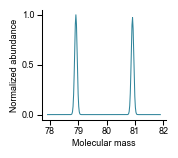

In [3]:
# Generate theoretical isotopic pattern for Bromine
peptide = {'Br':1}
theoretical_isotopic_cluster = isotopic_variants(peptide, npeaks = 5)
mz_grid, intensity = generate_isotopic_profile(theoretical_isotopic_cluster)
# create figure
fig, ax = plt.subplots(figsize=(1.6, 1.4))
ax.plot(mz_grid, intensity, color = '#31859B', linestyle = '-', linewidth = 0.75, alpha = 1.0)
ax.set_xlabel('Molecular mass')
ax.set_ylabel('Normalized abundance')
ax.set_xticks([78, 79, 80, 81, 82])
ax.set_yticks([0, 0.5, 1.0])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout(pad = 0.1)
plt.show()

### Supplementary Figure 1. Nine_BrIS_peptides_isotopic_pattern

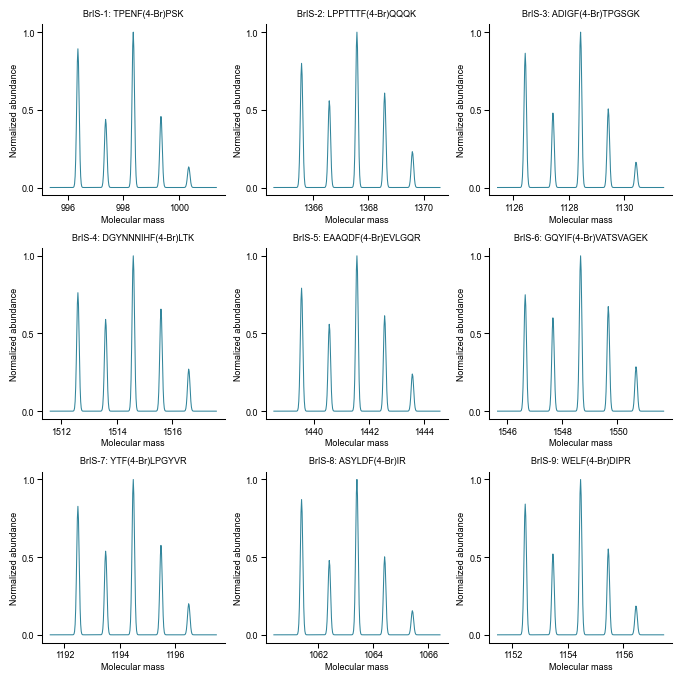

In [4]:
BrIS = {
    'TPENFPSK':'TPENF(4-Br)PSK', 
    'LPPTTTFQQQK':'LPPTTTF(4-Br)QQQK',
    'ADIGFTPGSGK':'ADIGF(4-Br)TPGSGK',
    'DGYNNNIHFLTK':'DGYNNNIHF(4-Br)LTK',
    'EAAQDFEVLGQR':'EAAQDF(4-Br)EVLGQR', 
    'GQYIFVATSVAGEK':'GQYIF(4-Br)VATSVAGEK',
    'YTFLPGYVR':'YTF(4-Br)LPGYVR', 
    'ASYLDFIR':'ASYLDF(4-Br)IR', 
    'WELFDIPR':'WELF(4-Br)DIPR'
}

# create subplot
fig, axes = plt.subplots(3, 3, figsize=(6.8, 6.8))
axes = axes.flatten() 
for idx, (peptide, modified_peptide) in enumerate(BrIS.items()):
    composition = dict(mass.Composition(sequence=peptide))
    composition['H'] = composition['H'] - 1
    composition['Br'] = 1
    theoretical_isotopic_cluster = isotopic_variants(composition, npeaks = 5)
    mz_grid, intensity = generate_isotopic_profile(theoretical_isotopic_cluster)
    ax = axes[idx]
    ax.plot(mz_grid, intensity, color = '#31859B', linestyle = '-', linewidth = 0.75, alpha = 1.0)
    ax.set_xlabel('Molecular mass')
    ax.set_ylabel('Normalized abundance')
    BrIS_ID = f'BrIS-{idx + 1}'
    ax.set_title(f'{BrIS_ID}: {modified_peptide}', loc = 'center')
    ax.set_yticks([0, 0.5, 1.0])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.tight_layout(pad = 1)
# save figure
plt.show()